In [3]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/2_wake_vs_sleep_network")
FIG_DIR.mkdir(exist_ok=True, parents=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [5]:
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    desc_add="clean",
    load_eog=False
)

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
print(desc_add)


clean-original-sleep-incl-nrem3-flame


In [10]:
from nilearn.glm import threshold_stats_img
import numpy as np 

def network_summary(contrast, yeo_data, names, desc_add):
    data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
    z_img     = data.t_stat
    brain_mask = data.mask 
    
    # FDR + cluster extent, computed once over the brain
    thr_map, thr = threshold_stats_img(
        data.z_stat , alpha=0.05, height_control="fdr",
        cluster_threshold=20, two_sided=True, mask_img=brain_mask,
    )
    
    z, sig = z_img.get_fdata(), thr_map.get_fdata() != 0
    out = {}
    for k, name in enumerate(names, start=1):
        print(k, name)
        m = yeo_data == k
        v, s = z[m], sig[m]
        out[name] = dict(mean_z=v.mean(), median_z=np.median(v),
                         pct_sig=100 * s.mean(),
                         # rat_pos_sig=((v[s] > 0).mean() if s.any() else np.nan) / ((v[s] < 0).mean() if s.any() else np.nan),
                         rat_pos=(v > 0).mean(),#, / ((v < 0).mean() if (v < 0).mean() > 0 else 1),
                         std=v.std(),
                         )
    return out


In [12]:
from nilearn import image
from nilearn import datasets

network_names = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']
contrasts = ("mreyemove_W", "mreyemove_S")

yeo = datasets.fetch_atlas_yeo_2011(n_networks=7, thickness="thick")
yeo_img = yeo.maps
contrast_map = {contrast: mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)[0].t_stat for contrast in contrasts}

yeo_resampled = image.resample_to_img(yeo_img, contrast_map[contrasts[0]], interpolation="nearest", force_resample=True, copy_header=True)
yeo_data = yeo_resampled.get_fdata() 
if yeo_data.ndim == 4:
    yeo_data = yeo_data[:,:,:,0]

wake_res  = network_summary("mreyemove_W",  yeo_data, network_names, desc_add)
sleep_res = network_summary("mreyemove_S", yeo_data, network_names, desc_add)


[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011
1 Visual
2 Somatomotor
3 Dorsal Attention
4 Ventral Attention
5 Limbic
6 Frontoparietal
7 Default
1 Visual
2 Somatomotor
3 Dorsal Attention
4 Ventral Attention
5 Limbic
6 Frontoparietal
7 Default
Visual       mean_z W=+2.43 S=+2.29 Δ=+0.15  %sig W=42.4 S=31.8    + W= 0.8 S= 0.9
Somatomotor  mean_z W=+0.07 S=-0.59 Δ=+0.66  %sig W= 2.3 S= 0.5    + W= 0.5 S= 0.2
Dorsal Attention mean_z W=+0.39 S=+0.32 Δ=+0.06  %sig W= 3.0 S= 4.5    + W= 0.5 S= 0.5
Ventral Attention mean_z W=+0.19 S=-1.05 Δ=+1.24  %sig W= 2.0 S= 8.1    + W= 0.5 S= 0.2
Limbic       mean_z W=-0.30 S=-0.08 Δ=-0.22  %sig W= 0.0 S= 0.0    + W= 0.1 S= 0.1
Frontoparietal mean_z W=-1.15 S=-1.93 Δ=+0.79  %sig W= 8.8 S=28.6    + W= 0.1 S= 0.0
Default      mean_z W=-1.32 S=-0.88 Δ=-0.44  %sig W=11.3 S= 7.4    + W= 0.1 S= 0.2



Stat: median_z
Network: Visual 
Wake: 2.6689494848251343, Sleep: 2.3755582571029663
Network: Dorsal Attention 
Wake: 0.1876019760966301, Sleep: 0.20205015689134598
Network: Ventral Attention 
Wake: 0.16427939385175705, Sleep: -1.0077237486839294
Network: Somatomotor 
Wake: 0.11270114034414291, Sleep: -0.5753300189971924
Network: Limbic 
Wake: 0.0, Sleep: 0.0
Network: Frontoparietal 
Wake: -1.30107843875885, Sleep: -2.046178102493286
Network: Default 
Wake: -1.5740758180618286, Sleep: -0.8459910750389099

Stat: pct_sig
Network: Visual 
Wake: 42.40275526742302, Sleep: 31.82739059967585
Network: Dorsal Attention 
Wake: 3.0419373892498522, Sleep: 4.48907265209687
Network: Ventral Attention 
Wake: 2.013201320132013, Sleep: 8.085808580858085
Network: Somatomotor 
Wake: 2.312800549576368, Sleep: 0.5037783375314862
Network: Limbic 
Wake: 0.0390625, Sleep: 0.0
Network: Frontoparietal 
Wake: 8.751431844215348, Sleep: 28.568155784650628
Network: Default 
Wake: 11.33898053202556, Sleep: 7.4305245

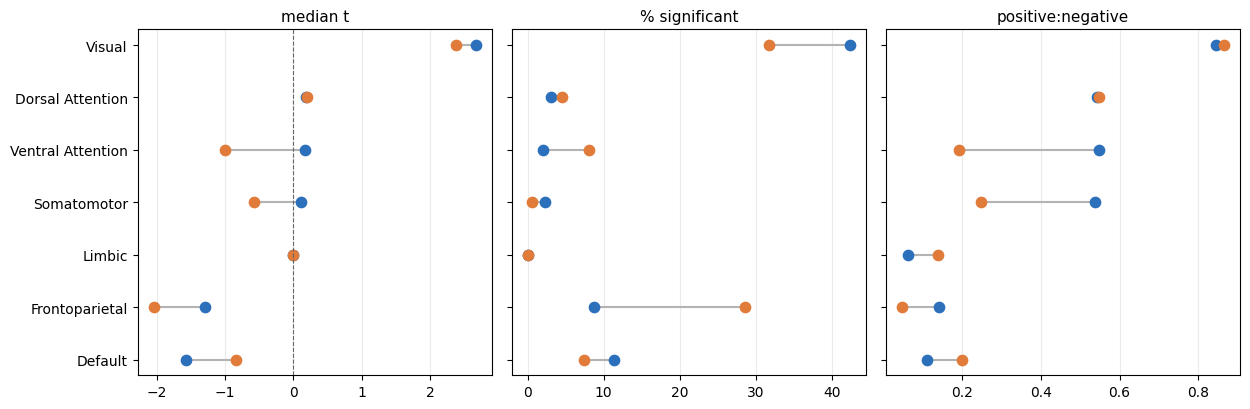

In [16]:
import numpy as np
import matplotlib.pyplot as plt

metrics = [
    ('median_z', 'median t', True),          # signed → zero line
    ('pct_sig', '% significant', False),
    # ('pct_pos_sig', '% positive | sig', False),
    # ('mean_z', 'mean z', True),          # signed → zero line
    # ("std", "std", False),
    ('rat_pos', 'positive:negative', False),
]

label_mapping = {
    
}
order = sorted(network_names, key=lambda n: wake_res[n]['median_z'], reverse=True)
y = np.arange(len(order))[::-1]                  # strongest at top
c_w, c_s = '#2C6FBB', '#E07B39'                  # wake, sleep

fig, axes = plt.subplots(1, len(metrics), figsize=(4.2 * len(metrics), 4.2),
                         sharey=True)

for ax, (key, label, signed) in zip(axes, metrics):
    print(f"\nStat: {key}")
    for yi, net in zip(y, order):
        w, s = wake_res[net][key], sleep_res[net][key]
        print(f"Network: {net} \nWake: {w}, Sleep: {s}")
        if np.isfinite(w) and np.isfinite(s):
            ax.plot([w, s], [yi, yi], color='0.7', lw=1.5, zorder=1)
        if np.isfinite(w):
            ax.scatter(w, yi, color=c_w, s=55, zorder=2)
        if np.isfinite(s):
            ax.scatter(s, yi, color=c_s, s=55, zorder=2)
    if signed:
        ax.axvline(0, color='0.4', lw=0.8, ls='--')
    ax.set_title(label, fontsize=11)
    ax.grid(axis='x', color='0.92'); ax.set_axisbelow(True)

axes[0].set_yticks(y); axes[0].set_yticklabels(order)
fig.tight_layout()
plt.savefig(FIG_DIR / "diffs.svg", dpi=300)
plt.show()

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/nilearn/surface/surface.py:603: 

KeyboardInterrupt: 

KeyboardInterrupt: 

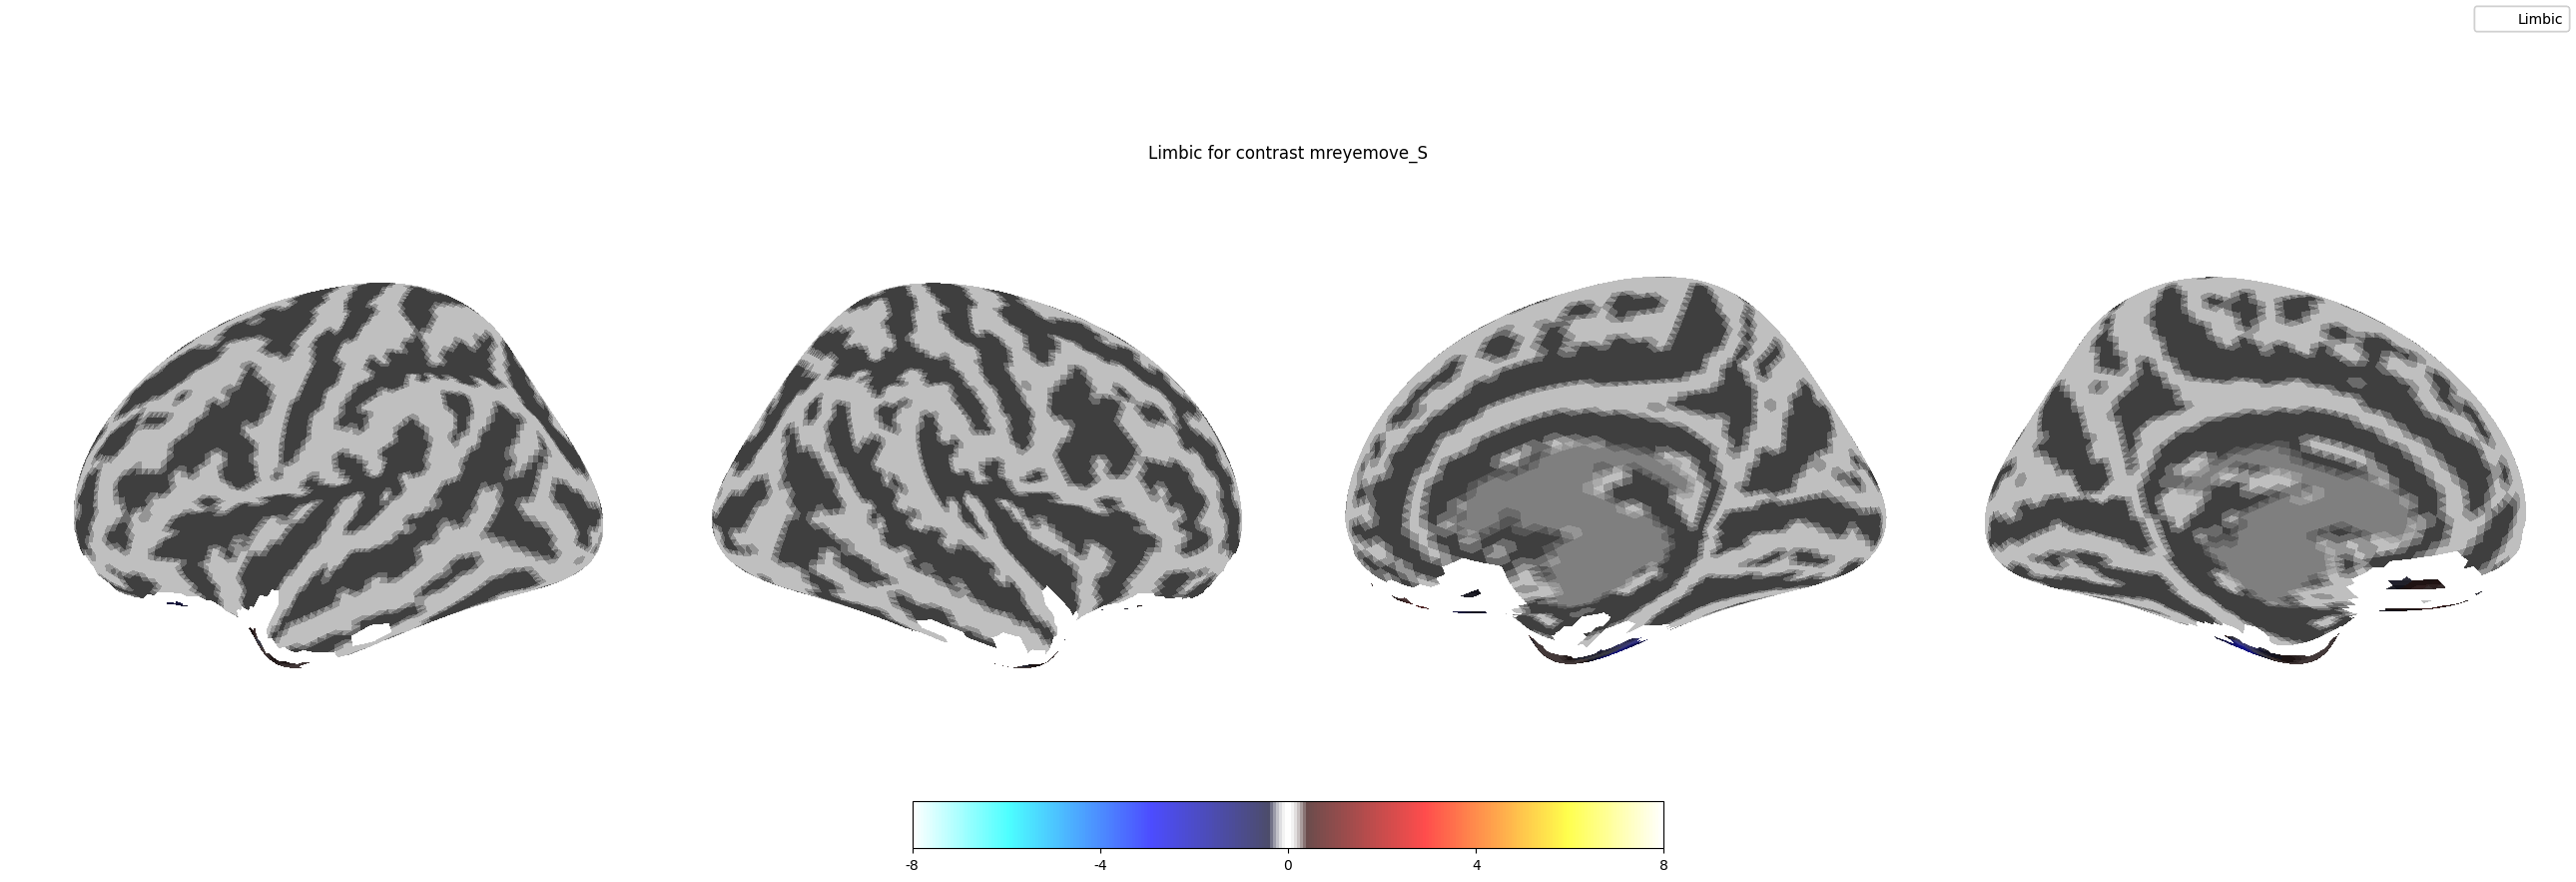

In [16]:
from mreyemove.plotting.glm_surface import plot_img_on_surf_with_contour
from nilearn.surface import vol_to_surf
from nilearn import image, datasets
from mreyemove.plotting.glm import custom_cmap
import numpy as np

# Load Yeo 7 atlas and resample to cope space
surf_mesh = "fsaverage7"
fsaverage7 = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    
roi_surf = {}
proj_kwargs = dict(interpolation="linear", radius=3.0, kind="line", n_samples=10)

output_dir = FIG_DIR / "masks"
output_dir.mkdir(parents=True, exist_ok=True)

for i, name in enumerate(network_names):
    idx = i + 1
    outside = (yeo_data != idx)

    for contrast in contrasts:
        base = contrast_map[contrast]
        data = base.get_fdata().copy()
        data[outside] = np.nan
        t_masked = image.new_img_like(base, data, copy_header=True)

        # contour = boundary of the region that will actually be coloured.
        # a vertex is "in" iff the masked map projects to a finite value there,
        # using the SAME projection the plot function uses internally.
        tex_l = vol_to_surf(t_masked, fsaverage7["pial_left"],  **proj_kwargs)
        tex_r = vol_to_surf(t_masked, fsaverage7["pial_right"], **proj_kwargs)
        roi_surf = {
            "left":  np.where(np.isfinite(tex_l), idx, 0).astype(int),
            "right": np.where(np.isfinite(tex_r), idx, 0).astype(int),
        }

        plot_img_on_surf_with_contour(
            surf_mesh=surf_mesh,
            stat_map=t_masked,
            roi_map=roi_surf,
            levels=[idx],
            labels=[name],
            contour_width=2,
            colors=["w"],
            vmin=-8, vmax=8,
            cmap=custom_cmap(),
            inflate=True,
            bg_on_data=True,
            legend=True,
            title=f"{name} for contrast {contrast}",
            output_file=output_dir / f"{name}_{contrast}_fs5",
        )